In [172]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)


# Task 1 — Maths & Adv Stats

## M1 Descriptive Statistics

Observed n: 184
Mean: 49.74440217391305
Median: 50.2
Sample Standard Deviation: 10.835872254207478


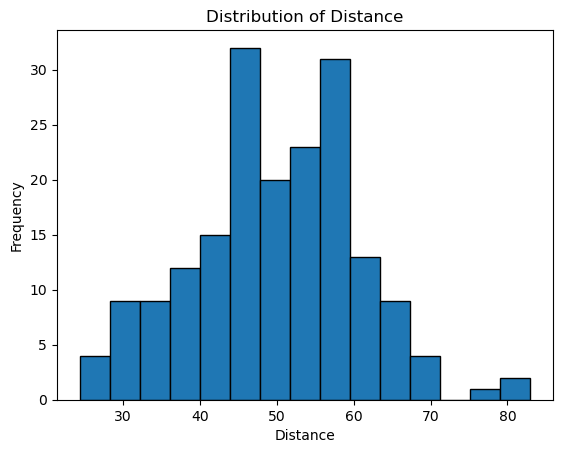

In [173]:
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df = pd.read_csv("data/raw/set_b.csv")

# Remove exact duplicates
df = df.drop_duplicates()

# Train/Test split
from sklearn.model_selection import train_test_split

fit_val, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["late"],
    random_state=42
)

fit, val = train_test_split(
    fit_val,
    test_size=0.20,
    stratify=fit_val["late"],
    random_state=42
)

# Observed distance values only
distance = fit["distance"].dropna()

print("Observed n:", distance.count())
print("Mean:", distance.mean())
print("Median:", distance.median())
print("Sample Standard Deviation:", distance.std(ddof=1))

# Histogram
plt.hist(distance, bins=15, edgecolor="black")
plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

## M2 Statistical Inference

In [174]:
# Distance values for each group
g1 = fit.loc[fit["group"] == "G1", "distance"].dropna()
g2 = fit.loc[fit["group"] == "G2", "distance"].dropna()

# H0: Mean distance of G1 = Mean distance of G2
# H1: Mean distance of G1 != Mean distance of G2

t_stat, p_value = stats.ttest_ind(
    g1,
    g2,
    equal_var=False
)

print("G1 count:", len(g1))
print("G2 count:", len(g2))
print("t-statistic:", t_stat)
print("p-value:", p_value)

# 95% CI for overall observed mean
distance = fit["distance"].dropna()

mean = distance.mean()
sem = stats.sem(distance)
df_degree = len(distance) - 1

ci = stats.t.interval(
    0.95,
    df_degree,
    loc=mean,
    scale=sem
)

print("95% Confidence Interval:", ci)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Do not reject H0")

G1 count: 104
G2 count: 80
t-statistic: 0.7061612423464614
p-value: 0.48105881393425987
95% Confidence Interval: (np.float64(48.16829889365394), np.float64(51.320505454172164))
Do not reject H0


## M 3 Linear Algebra

In [175]:
# Select rows complete for distance and traffic
data = fit[["distance", "traffic"]].dropna()

X = data.to_numpy()

# Mean
mean = X.mean(axis=0)

# Manual centering
X_centered = X - mean

print("Centered Matrix:")
print(X_centered)

# Sample covariance matrix
cov_matrix = (
    X_centered.T @ X_centered
) / (len(X_centered) - 1)

print("\nCovariance Matrix:")
print(cov_matrix)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("\nEigenvalues:")
print(eigenvalues)

# Largest eigenvalue
largest_index = np.argmax(eigenvalues)

largest_eigenvalue = eigenvalues[largest_index]

# Variance share
variance_share = (
    largest_eigenvalue /
    eigenvalues.sum()
)

print("\nLargest Eigenvalue:", largest_eigenvalue)
print("Variance Share:", variance_share)

# Principal direction
principal_direction = eigenvectors[:, largest_index]

print("Principal Direction:")
print(principal_direction)

Centered Matrix:
[[  6.10559783  -6.78494565]
 [  2.00559783 -12.83494565]
 [  9.24559783  15.84505435]
 [  8.29559783   3.97505435]
 [  7.85559783 -11.74494565]
 [  6.58559783  -3.72494565]
 [-21.01440217  10.95505435]
 [ 30.19559783   9.52505435]
 [  7.54559783  -0.59494565]
 [  6.72559783  -4.39494565]
 [  8.63559783  -6.25494565]
 [-25.40440217  -8.51494565]
 [-14.63440217 -13.81494565]
 [ -4.71440217   1.85505435]
 [-11.47440217   0.88505435]
 [ 18.37559783 -10.08494565]
 [ -1.12440217  -4.54494565]
 [-12.59440217   6.06505435]
 [  4.56559783 -12.80494565]
 [ -3.58440217   3.59505435]
 [ -7.74440217  17.62505435]
 [ 12.35559783   5.15505435]
 [ -3.15440217  -4.10494565]
 [  5.76559783  17.31505435]
 [-11.29440217  -9.08494565]
 [ -1.93440217   4.67505435]
 [ -4.43440217  -5.33494565]
 [  1.50559783   8.50505435]
 [ -4.46440217  -3.64494565]
 [  0.98559783   3.38505435]
 [ 13.18559783  -7.21494565]
 [ -8.78440217 -19.41494565]
 [-13.30440217   2.57505435]
 [ 19.76559783  13.4550543

# Task 2 Data Preprocessing & Feature Engineering

## F1 — Audit and Partition

In [176]:
# df = pd.read_csv("data/raw/set_b.csv")

print("Original Shape:", df.shape)

print("\nExact Duplicates:")
print(df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Counts:")
print(df["late"].value_counts())

# Remove exact duplicates
df = df.drop_duplicates()

print("\nShape After Removing Duplicates:", df.shape)
print("Unique Records:", df["record_id"].nunique())

Original Shape: (300, 7)

Exact Duplicates:
0

Missing Values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Target Counts:
late
0    155
1    145
Name: count, dtype: int64

Shape After Removing Duplicates: (300, 7)
Unique Records: 300


## F2 — Transform and Engineer

In [177]:
from sklearn.model_selection import train_test_split

# 80% fit+validation, 20% test
fit_val, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["late"],
    random_state=42
)

# 20% of training partition = validation
fit, validation = train_test_split(
    fit_val,
    test_size=0.20,
    stratify=fit_val["late"],
    random_state=42
)

print("Fit:", len(fit))
print("Validation:", len(validation))
print("Test:", len(test))

Fit: 192
Validation: 48
Test: 60


In [178]:
split_ids = pd.concat([
    fit[["record_id"]].assign(partition="fit"),
    validation[["record_id"]].assign(partition="validation"),
    test[["record_id"]].assign(partition="test")
])

split_ids.to_csv(
    "outputs/splits.csv",
    index=False
)

print(split_ids.head())

     record_id partition
288        289       fit
73          74       fit
259        260       fit
280        281       fit
243        244       fit


In [179]:
import os

os.makedirs("outputs", exist_ok=True)

In [180]:
assert set(fit["record_id"]).isdisjoint(validation["record_id"])
assert set(fit["record_id"]).isdisjoint(test["record_id"])
assert set(validation["record_id"]).isdisjoint(test["record_id"])

print("All partition IDs are disjoint.")

All partition IDs are disjoint.


## F2 — Imputation + Encoding + Feature Engineering

In [181]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [
    "distance",
    "load",
    "traffic",
    "staff"
]

# -------------------------
# Numeric Imputation
# -------------------------

imputer = SimpleImputer(strategy="median")

imputer.fit(
    fit[numeric_cols]
)

SimpleImputer(strategy='median')

In [182]:
def prepare_numeric(data):

    result = pd.DataFrame(
        imputer.transform(data[numeric_cols]),
        columns=numeric_cols,
        index=data.index
    )

    # Required engineered feature
    result["engineered_feature"] = (
        result["load"] /
        (result["staff"] + 1)
    )

    return result


fit_num = prepare_numeric(fit)
val_num = prepare_numeric(validation)
test_num = prepare_numeric(test)

In [183]:
scaler = StandardScaler()

scaler.fit(fit_num)

fit_scaled = scaler.transform(fit_num)
val_scaled = scaler.transform(val_num)
test_scaled = scaler.transform(test_num)

In [184]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(fit[["group"]])

fit_group = encoder.transform(
    fit[["group"]]
)

val_group = encoder.transform(
    validation[["group"]]
)

test_group = encoder.transform(
    test[["group"]]
)

In [185]:
X_fit = np.hstack([
    fit_scaled,
    fit_group
])

X_val = np.hstack([
    val_scaled,
    val_group
])

X_test = np.hstack([
    test_scaled,
    test_group
])

y_fit = fit["late"].values
y_val = validation["late"].values
y_test = test["late"].values

print("X_fit shape:", X_fit.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("All values finite:",
      np.isfinite(X_fit).all())

X_fit shape: (192, 7)
X_val shape: (48, 7)
X_test shape: (60, 7)
All values finite: True


In [186]:
numeric_features = [
    "distance",
    "load",
    "traffic",
    "staff",
    "engineered_feature"
]

group_features = encoder.get_feature_names_out(
    ["group"]
)

feature_names = list(
    numeric_features
) + list(group_features)

print("Feature Names:")
print(feature_names)

Feature Names:
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


# Task 3 Supervised Learning 


## S1 — Baseline and Classifie

In [187]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_fit,
    y_fit
)

dummy_pred = dummy.predict(X_test)

In [188]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_fit,
    y_fit
)

log_pred = log_model.predict(X_test)

log_probability = (
    log_model.predict_proba(X_test)[:, 1]
)

## S2 — Holdout Evaluation

In [189]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(name, y_true, y_pred):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true, y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

dummy_result = evaluate_model(
    "Dummy",
    y_test,
    dummy_pred
)

log_result = evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred
)

results = pd.DataFrame([
    dummy_result,
    log_result
])

print(results)

                 Model  Accuracy  Precision    Recall        F1
0                Dummy  0.516667   0.000000  0.000000  0.000000
1  Logistic Regression  0.850000   0.884615  0.793103  0.836364


## Matrix

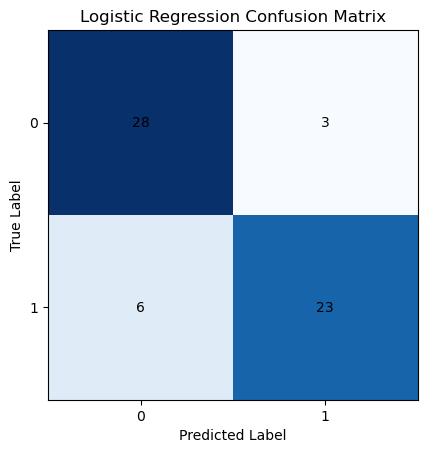

In [190]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    log_pred
)

plt.imshow(cm,cmap="Blues")


plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["0", "1"]
)

plt.yticks(
    [0, 1],
    ["0", "1"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [191]:
predictions = pd.DataFrame({
    "record_id": test["record_id"].values,
    "true_label": y_test,
    "predicted_label": log_pred,
    "class_1_probability": log_probability
})

predictions.to_csv(
    "outputs/logistic_test_predictions.csv",
    index=False
)

print(predictions.head())

   record_id  true_label  predicted_label  class_1_probability
0         50           0                0             0.034625
1        231           0                0             0.074453
2        297           0                0             0.006790
3         97           0                0             0.112015
4        285           0                0             0.040311


## S3 — Interpretation

- **False Positive:** The model predicts a positive case when it is actually negative.
- **False Negative:** The model predicts a negative case when it is actually positive.
- If the test **recall/F1-score is better than the baseline**, the classifier provides useful improvement, even if its accuracy is not very high.

# Task 4 Unsupervised Leaerning 

## U1 — K-Means and Selection

In [192]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Only numeric transformed features
X_cluster = X_fit[:, :5]

results = []

for k in [2, 3, 4]:

    model = KMeans(n_clusters=k,n_init=10,random_state=42)

    labels = model.fit_predict(X_cluster)

    inertia = model.inertia_

    silhouette = silhouette_score(X_cluster,labels)

    results.append({"k": k,"inertia": inertia,"silhouette_score": silhouette})

cluster_results = pd.DataFrame(results)

print(cluster_results)

   k     inertia  silhouette_score
0  2  719.632089          0.246337
1  3  599.659398          0.207147
2  4  535.383548          0.190232


c:\Users\patel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\patel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\patel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Best K


In [193]:
best_k = (
    cluster_results
    .sort_values(
        ["silhouette_score", "k"],
        ascending=[False, True]
    )
    .iloc[0]["k"]
)

best_k = int(best_k)

print("Best K:", best_k)

Best K: 2


In [194]:
kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    X_cluster
)

fit_clustered = fit.copy()

fit_clustered["cluster"] = cluster_labels

print(
    fit_clustered[
        ["record_id", "cluster"]
    ].head()
)

c:\Users\patel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


     record_id  cluster
288        289        0
73          74        1
259        260        0
280        281        0
243        244        0


In [195]:
profile = (
    fit_clustered
    .groupby("cluster")[
        ["distance",
         "load",
         "traffic",
         "staff"]
    ]
    .mean()
)

print(profile)

profile.to_csv(
    "outputs/cluster_profiles.csv"
)

         distance       load    traffic      staff
cluster                                           
0        48.39197  46.995000  49.066269  54.035000
1        53.17750  57.729286  49.856207  41.426724


# Task 5 — Deep Learning up to ANN

## D1 — ANN Architecture and Compilation

In [196]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class ANN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):

        return self.model(x).squeeze()

In [197]:
model = ANN(
    X_fit.shape[1]
)

print(model)

ANN(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [198]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable Parameters:",
    trainable_params
)

Trainable Parameters: 273


## D2 — Training and Validation

In [199]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_fit,dtype=torch.float32)

y_train_tensor = torch.tensor(y_fit,dtype=torch.float32)

X_val_tensor = torch.tensor(X_val,dtype=torch.float32)

y_val_tensor = torch.tensor(y_val,dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)

In [200]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [201]:
history = []

best_val_loss = float("inf")

best_model = None

patience = 5

counter = 0

for epoch in range(50):

    model.train()

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        output = model(X_batch)

        loss = criterion( output, y_batch)

        loss.backward()

        optimizer.step()

    # Training loss
    model.eval()

    with torch.no_grad():

        train_output = model(X_train_tensor)

        train_loss = criterion(train_output,y_train_tensor).item()

        val_output = model( X_val_tensor)

        val_loss = criterion(val_output,y_val_tensor).item()

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f}, "
        f"Validation={val_loss:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping")

            break

Epoch 1: Train=0.6967, Validation=0.7028
Epoch 2: Train=0.6908, Validation=0.6998
Epoch 3: Train=0.6834, Validation=0.6962
Epoch 4: Train=0.6747, Validation=0.6916
Epoch 5: Train=0.6644, Validation=0.6856
Epoch 6: Train=0.6527, Validation=0.6781
Epoch 7: Train=0.6388, Validation=0.6692
Epoch 8: Train=0.6229, Validation=0.6584
Epoch 9: Train=0.6052, Validation=0.6456
Epoch 10: Train=0.5860, Validation=0.6305
Epoch 11: Train=0.5653, Validation=0.6135
Epoch 12: Train=0.5433, Validation=0.5924
Epoch 13: Train=0.5204, Validation=0.5716
Epoch 14: Train=0.4947, Validation=0.5470
Epoch 15: Train=0.4704, Validation=0.5248
Epoch 16: Train=0.4462, Validation=0.5025
Epoch 17: Train=0.4252, Validation=0.4839
Epoch 18: Train=0.4068, Validation=0.4680
Epoch 19: Train=0.3930, Validation=0.4570
Epoch 20: Train=0.3815, Validation=0.4461
Epoch 21: Train=0.3720, Validation=0.4391
Epoch 22: Train=0.3637, Validation=0.4323
Epoch 23: Train=0.3575, Validation=0.4274
Epoch 24: Train=0.3516, Validation=0.4230
E

In [202]:
model.load_state_dict(
    best_model
)

print(
    "Actual epochs:",
    len(history)
)

Actual epochs: 34


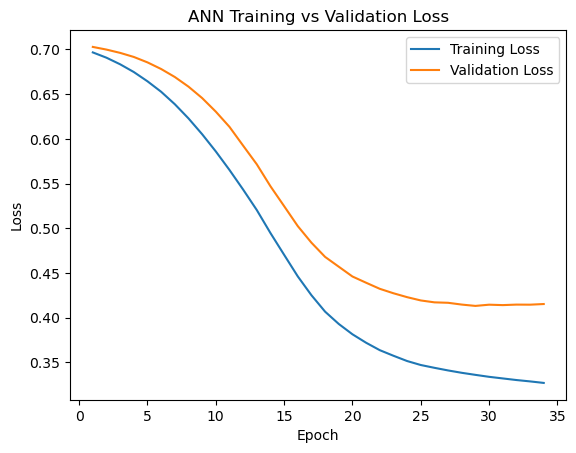

In [203]:
history_df = pd.DataFrame(
    history
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ANN Training vs Validation Loss"
)

plt.legend()

plt.show()

## D3 — Comparison and Evidence


In [204]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(logits).numpy()

ann_pred = (probabilities >= 0.5).astype(int)

In [205]:
ann_accuracy = accuracy_score(y_test,ann_pred)

ann_precision = precision_score( y_test,ann_pred,zero_division=0)

ann_recall = recall_score(y_test,ann_pred,zero_division=0)

ann_f1 = f1_score(y_test,ann_pred,zero_division=0)

print("ANN Accuracy:", ann_accuracy)
print("ANN Precision:", ann_precision)
print("ANN Recall:", ann_recall)
print("ANN F1:", ann_f1)

ANN Accuracy: 0.8166666666666667
ANN Precision: 0.875
ANN Recall: 0.7241379310344828
ANN F1: 0.7924528301886793


In [206]:
comparison = pd.DataFrame({

    "Model": ["Logistic Regression","ANN"],

    "Accuracy": [accuracy_score(y_test, log_pred),ann_accuracy],

    "Precision": [precision_score(y_test,log_pred,zero_division=0),ann_precision],

    "Recall": [recall_score(y_test,log_pred,zero_division=0),ann_recall],

    "F1": [f1_score(y_test,log_pred,zero_division=0 ),ann_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.850000   0.884615  0.793103  0.836364
1                  ANN  0.816667   0.875000  0.724138  0.792453


In [207]:
ann_predictions = pd.DataFrame({

    "record_id":test["record_id"].values,

    "true_label":y_test,

    "predicted_label":ann_pred,

    "class_1_probability":probabilities
})

ann_predictions.to_csv(
    "outputs/ann_test_predictions.csv",
    index=False
)